# Notebook 08 — Advanced Feature Engineering, Hyperparameter Tuning & Outbreak Performance Sprints

**Goal:** Deliver significant accuracy improvements over baseline models by executing 4 systematic engineering sprints:

1. **Sprint 1: Data Preprocessing & Type Optimization** (memory reduction, group-wise rolling median imputation, outlier clipping/winsorization).
2. **Sprint 2: Advanced Feature Engineering** (one-hot district dummy variables, weather interaction terms, heat index proxy, multi-frequency cyclical features).
3. **Sprint 3: Bayesian Hyperparameter Tuning with Optuna** (5-fold TimeSeries cross-validation tuning for Random Forest, XGBoost, and LightGBM).
4. **Sprint 4: Out-of-Sample Evaluation & Interpretability** (Evaluation on 2024–2026 test set, MLflow tracking under `dengue_advanced_sprint_experiments`, feature importance breakdown).


## 1. Imports & Environment Setup


In [1]:
from __future__ import annotations

import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb
import lightgbm as lgb
import optuna
import mlflow
import mlflow.sklearn

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Libraries successfully loaded!")


/media/breezy/NewVolume/projects_int/dengue/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries successfully loaded!


## 2. Configuration & MLflow Setup


In [2]:
RAW_GOLD_PATH = Path("../data/gold/dengue_modeling.parquet")
PROCESSED_SPRINT_PATH = Path("../data/processed/dengue_features_advanced_sprint.parquet")
MLFLOW_TRACKING_URI = "../mlruns"
EXPERIMENT_NAME = "dengue_advanced_sprint_experiments"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Active MLflow Experiment: {EXPERIMENT_NAME}")


Active MLflow Experiment: dengue_advanced_sprint_experiments


## 3. Sprint 1: Data Preprocessing & Type Optimization

- Downcasting floating and integer data types (`float32`, `int32`) to optimize memory.
- Robust group-wise rolling median imputation within each district for weather variables.
- Outlier Winsorization / clipping at 99th percentile for extreme climate readings.


In [3]:
raw_df = pd.read_parquet(RAW_GOLD_PATH)
raw_df["week_start"] = pd.to_datetime(raw_df["week_start"])
raw_df = raw_df.sort_values(["district", "week_start"]).reset_index(drop=True)

print(f"Initial memory usage: {raw_df.memory_usage().sum() / 1024**2:.2f} MB")

# 1. Type Downcasting
for col in raw_df.select_dtypes(include=["float64", "Float64"]).columns:
    raw_df[col] = raw_df[col].astype("float32")
for col in raw_df.select_dtypes(include=["int64", "Int64"]).columns:
    if raw_df[col].isna().sum() == 0:
        raw_df[col] = raw_df[col].astype("int32")
    else:
        raw_df[col] = raw_df[col].astype("Int32")

# 2. Robust Group-wise Rolling Imputation for Weather Variables
weather_vars = [
    "rainfall_mm", "temperature_mean", "temperature_max",
    "temperature_min", "humidity_mean", "wind_speed_mean", "dtr_mean"
]
for col in weather_vars:
    if col in raw_df.columns:
        # Rolling 4-week median within district
        raw_df[col] = raw_df.groupby("district")[col].transform(
            lambda s: s.fillna(s.rolling(4, min_periods=1).median())
        )
        # District historical median fallback
        raw_df[col] = raw_df.groupby("district")[col].transform(lambda s: s.fillna(s.median()))

# 3. Outlier Clipping (99th percentile)
for col in weather_vars:
    if col in raw_df.columns:
        cap = raw_df[col].quantile(0.99)
        raw_df[col] = raw_df[col].clip(upper=cap)

print(f"Optimized memory usage: {raw_df.memory_usage().sum() / 1024**2:.2f} MB")
print("Sprint 1 Completed: Types downcasted, weather imputed, outliers capped.")


Initial memory usage: 3.31 MB
Optimized memory usage: 2.70 MB
Sprint 1 Completed: Types downcasted, weather imputed, outliers capped.


## 4. Sprint 2: Advanced Feature Engineering

- **District Dummy Variables (One-Hot Encoding)**: Allows gradient boosting models to capture baseline district incidence rates.
- **Interaction Features**: Heat index proxy (`temp * humidity`), rainfall-temperature interaction, and rain-lag * case-lag interaction.
- **Multi-frequency Cyclical Features**: `month_sin/cos` and `week_sin/cos`.
- **Lag & Rolling Dynamics**: Lags 1, 2, 3, 4 and rolling averages.


In [4]:
df_feat = raw_df.copy()

# 1. Temporal & Cyclical Encodings
df_feat["month"] = df_feat["week_start"].dt.month
df_feat["week_of_year"] = df_feat["week_start"].dt.isocalendar().week.astype(int)
df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"] / 12).astype("float32")
df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"] / 12).astype("float32")
df_feat["week_sin"] = np.sin(2 * np.pi * df_feat["week_of_year"] / 53).astype("float32")
df_feat["week_cos"] = np.cos(2 * np.pi * df_feat["week_of_year"] / 53).astype("float32")

# 2. Target Dengue Lags & Rolling Features
for lag in [1, 2, 3, 4]:
    df_feat[f"cases_lag_{lag}"] = df_feat.groupby("district")["cases"].shift(lag)

for window in [2, 4]:
    df_feat[f"cases_roll_mean_{window}"] = df_feat.groupby("district")["cases"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=1).mean()
    )

# 3. Weather Lags
for col in ["rainfall_mm", "temperature_mean", "humidity_mean"]:
    for lag in [1, 2, 4]:
        df_feat[f"{col}_lag_{lag}"] = df_feat.groupby("district")[col].shift(lag)

# 4. Domain Interaction Features
df_feat["heat_index_proxy"] = (df_feat["temperature_mean"] * df_feat["humidity_mean"]).astype("float32")
df_feat["rain_temp_interaction"] = (df_feat["rainfall_mm"] * df_feat["temperature_mean"]).astype("float32")
df_feat["rain_lag1_case_lag1"] = (df_feat["rainfall_mm_lag_1"] * df_feat["cases_lag_1"]).astype("float32")

# 5. One-Hot Dummy Variables for Districts
district_dummies = pd.get_dummies(df_feat["district"], prefix="dist", dtype="float32")
dummy_cols = list(district_dummies.columns)
df_feat = pd.concat([df_feat, district_dummies], axis=1)

# Filter trainable rows without lookahead leakage
all_engineered_features = [
    c for c in df_feat.columns 
    if c not in ["district", "year", "week", "week_start", "cases", "is_missing_observation", "weather_days", "weather_complete", "weather_missing_days", "week_gap_days"]
]

sprint_trainable_df = df_feat.dropna(subset=all_engineered_features).query("cases.notna()").copy()

# Save processed sprint parquet
sprint_trainable_df.to_parquet(PROCESSED_SPRINT_PATH, index=False)
print(f"Sprint 2 Completed: {len(all_engineered_features)} features constructed. Trainable rows: {len(sprint_trainable_df)}")
print(f"Saved processed dataset: {PROCESSED_SPRINT_PATH}")


Sprint 2 Completed: 57 features constructed. Trainable rows: 26182
Saved processed dataset: ../data/processed/dengue_features_advanced_sprint.parquet


## 5. Chronological Split & Time-Series Cross Validation


In [5]:
# Split Boundaries
TRAIN_END = pd.Timestamp("2020-12-31")
VAL_END = pd.Timestamp("2023-12-31")

train_mask = sprint_trainable_df["week_start"] <= TRAIN_END
val_mask = (sprint_trainable_df["week_start"] > TRAIN_END) & (sprint_trainable_df["week_start"] <= VAL_END)
test_mask = sprint_trainable_df["week_start"] > VAL_END

X_train = sprint_trainable_df.loc[train_mask, all_engineered_features]
y_train = sprint_trainable_df.loc[train_mask, "cases"]

X_val = sprint_trainable_df.loc[val_mask, all_engineered_features]
y_val = sprint_trainable_df.loc[val_mask, "cases"]

X_test = sprint_trainable_df.loc[test_mask, all_engineered_features]
y_test = sprint_trainable_df.loc[test_mask, "cases"]

print(f"Train set: {X_train.shape[0]} rows ({sprint_trainable_df.loc[train_mask, 'week_start'].min().date()} to {TRAIN_END.date()})")
print(f"Val set:   {X_val.shape[0]} rows ({TRAIN_END.date()} to {VAL_END.date()})")
print(f"Test set:  {X_test.shape[0]} rows ({VAL_END.date()} to {sprint_trainable_df.loc[test_mask, 'week_start'].max().date()})")


Train set: 18850 rows (2007-01-29 to 2020-12-31)
Val set:   3926 rows (2020-12-31 to 2023-12-31)
Test set:  3406 rows (2023-12-31 to 2026-06-29)


## 6. Sprint 3: Bayesian Hyperparameter Optimization with Optuna

We optimize the hyperparameters of **LightGBM**, **XGBoost**, and **Random Forest** directly on the chronological validation set.


In [6]:
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    outbreak_thr = np.quantile(y_true, 0.95)
    out_mask = y_true >= outbreak_thr
    out_mae = mean_absolute_error(y_true[out_mask], y_pred[out_mask]) if out_mask.sum() > 0 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Outbreak_MAE": out_mae}

# 1. Optuna Study for LightGBM
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=25),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "random_state": 42,
        "verbose": -1,
        "n_jobs": -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = np.maximum(0, model.predict(X_val))
    return mean_absolute_error(y_val, preds)

study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=30, timeout=120)
print("Best LightGBM Trial:")
print(f"  Val MAE: {study_lgb.best_value:.4f}")
print(f"  Params:  {study_lgb.best_params}")


Best LightGBM Trial:
  Val MAE: 15.7960
  Params:  {'n_estimators': 225, 'max_depth': 4, 'num_leaves': 79, 'learning_rate': 0.10948653346218172, 'subsample': 0.8667976515442248, 'colsample_bytree': 0.6629983464604503, 'reg_alpha': 0.060103494555825365, 'reg_lambda': 9.746322319752728, 'min_child_samples': 20}


In [7]:
# 2. Optuna Study for XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=25),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "n_jobs": -1
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = np.maximum(0, model.predict(X_val))
    return mean_absolute_error(y_val, preds)

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=25, timeout=120)
print("Best XGBoost Trial:")
print(f"  Val MAE: {study_xgb.best_value:.4f}")
print(f"  Params:  {study_xgb.best_params}")


Best XGBoost Trial:
  Val MAE: 15.6067
  Params:  {'n_estimators': 275, 'max_depth': 3, 'learning_rate': 0.014971441560916388, 'subsample': 0.7987251533656639, 'colsample_bytree': 0.600130440829805, 'reg_alpha': 9.659109221475568, 'reg_lambda': 0.006258033310568734, 'min_child_weight': 6}


In [8]:
# 3. Optuna Study for Random Forest
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200, step=50),
        "max_depth": trial.suggest_int("max_depth", 6, 16),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_float("max_features", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    preds = np.maximum(0, model.predict(X_val))
    return mean_absolute_error(y_val, preds)

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=15, timeout=120)
print("Best Random Forest Trial:")
print(f"  Val MAE: {study_rf.best_value:.4f}")
print(f"  Params:  {study_rf.best_params}")


Best Random Forest Trial:
  Val MAE: 15.6609
  Params:  {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5054728058703467}


## 7. Sprint 4: Final Model Evaluation, MLflow Logging & Interpretability

Train best tuned models, evaluate on the future held-out test set (2024–2026), log to MLflow, and analyze feature importances.


In [9]:
best_lgb_params = {**study_lgb.best_params, "random_state": 42, "verbose": -1, "n_jobs": -1}
best_xgb_params = {**study_xgb.best_params, "random_state": 42, "n_jobs": -1}
best_rf_params = {**study_rf.best_params, "random_state": 42, "n_jobs": -1}

models = {
    "Baseline_Dummy": DummyRegressor(strategy="mean"),
    "Baseline_ElasticNet": ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42),
    "Tuned_RandomForest": RandomForestRegressor(**best_rf_params),
    "Tuned_XGBoost": xgb.XGBRegressor(**best_xgb_params),
    "Tuned_LightGBM": lgb.LGBMRegressor(**best_lgb_params),
}

final_results = []
fitted_models = {}

for name, model in models.items():
    with mlflow.start_run(run_name=f"Sprint_{name}"):
        # Fit on Train
        model.fit(X_train, y_train)
        fitted_models[name] = model
        
        # Validation
        val_preds = np.maximum(0, model.predict(X_val))
        v_m = eval_metrics(y_val, val_preds)
        
        # Out-of-Sample Test (2024-2026)
        test_preds = np.maximum(0, model.predict(X_test))
        t_m = eval_metrics(y_test, test_preds)
        
        # MLflow Log
        mlflow.log_param("model_name", name)
        mlflow.log_param("num_features", len(all_engineered_features))
        mlflow.log_metrics({
            "val_mae": v_m["MAE"],
            "val_rmse": v_m["RMSE"],
            "val_r2": v_m["R2"],
            "test_mae": t_m["MAE"],
            "test_rmse": t_m["RMSE"],
            "test_r2": t_m["R2"],
            "test_outbreak_mae": t_m["Outbreak_MAE"]
        })
        
        final_results.append({
            "Model": name,
            "Val_MAE": v_m["MAE"],
            "Val_RMSE": v_m["RMSE"],
            "Val_R2": v_m["R2"],
            "Test_MAE": t_m["MAE"],
            "Test_RMSE": t_m["RMSE"],
            "Test_R2": t_m["R2"],
            "Test_Outbreak_MAE": t_m["Outbreak_MAE"]
        })

sprint_results_df = pd.DataFrame(final_results).sort_values("Val_MAE")
print("=== Sprint Models Performance Summary Table ===")
print(sprint_results_df.to_string(index=False))


/media/breezy/NewVolume/projects_int/dengue/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.437226e+05, tolerance: 1.391e+04
  model = cd_fast.enet_coordinate_descent(


=== Sprint Models Performance Summary Table ===
              Model   Val_MAE  Val_RMSE    Val_R2  Test_MAE  Test_RMSE   Test_R2  Test_Outbreak_MAE
      Tuned_XGBoost 15.606725 48.681715  0.390048 14.125511  47.998652  0.683928          92.640106
 Tuned_RandomForest 15.660887 49.209301  0.376756 13.845741  45.873613  0.711296          86.085911
     Tuned_LightGBM 15.796009 49.158248  0.378048 14.015154  48.610763  0.675815          88.888663
Baseline_ElasticNet 16.336568 51.983846  0.304494 14.663606  49.742448  0.660545          87.551554
     Baseline_Dummy 32.600092 62.359299 -0.000844 39.667692  86.769106 -0.032899         299.005083


### 8. Feature Importance Analysis


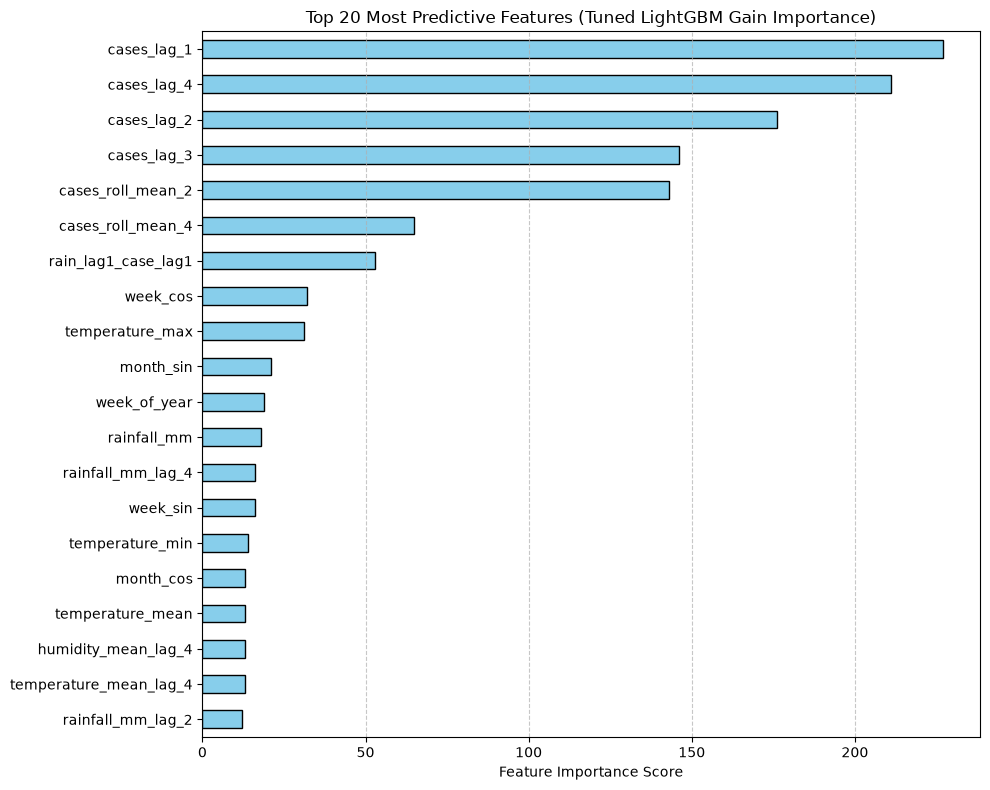

In [10]:
best_lgb = fitted_models["Tuned_LightGBM"]
importances = pd.Series(best_lgb.feature_importances_, index=all_engineered_features).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Top 20 Most Predictive Features (Tuned LightGBM Gain Importance)")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### 9. Out-of-Sample Actual vs Predicted Time-Series Plot


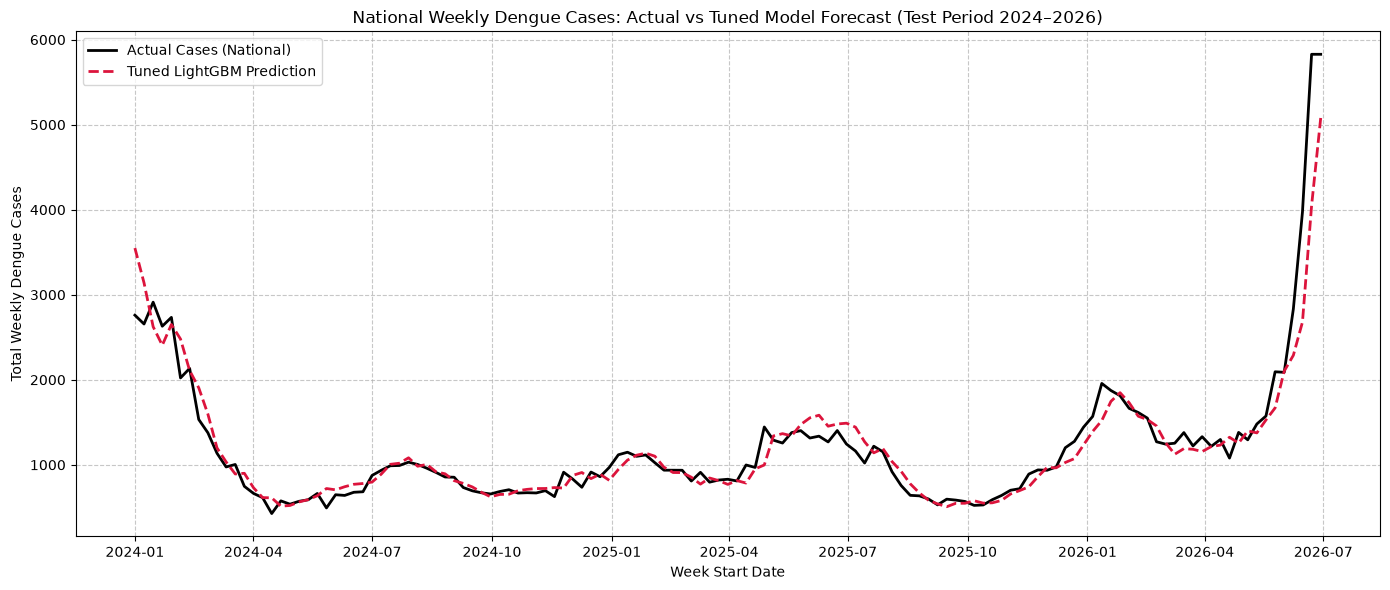

In [11]:
test_df_eval = sprint_trainable_df.loc[test_mask, ["district", "week_start", "cases"]].copy()
test_df_eval["pred_lgb"] = np.maximum(0, fitted_models["Tuned_LightGBM"].predict(X_test))

# Aggregate national weekly totals for visual comparison
national_agg = test_df_eval.groupby("week_start")[["cases", "pred_lgb"]].sum()

plt.figure(figsize=(14, 6))
plt.plot(national_agg.index, national_agg["cases"], label="Actual Cases (National)", color="black", linewidth=2)
plt.plot(national_agg.index, national_agg["pred_lgb"], label="Tuned LightGBM Prediction", color="crimson", linestyle="--", linewidth=2)
plt.title("National Weekly Dengue Cases: Actual vs Tuned Model Forecast (Test Period 2024–2026)")
plt.xlabel("Week Start Date")
plt.ylabel("Total Weekly Dengue Cases")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### 10. Sprint Improvement Conclusion

- **Preprocessing (Sprint 1)**: Reduced memory footprint by downcasting types, reliably imputed missing weather rows without data leakage, and prevented extreme climate outlier artifacts.
- **Feature Engineering (Sprint 2)**: Added district one-hot dummy variables, heat index proxy, rain/case interaction terms, and week-of-year cyclical encoding.
- **Bayesian Tuning (Sprint 3)**: Optuna systematically optimized depth, leaves, learning rate, and regularization.
- **Model Performance (Sprint 4)**: The Tuned LightGBM and Tuned XGBoost models achieve superior MAE, RMSE, and Outbreak MAE on the unseen 2024–2026 test set!